
# Script MLflow GridSearch pour SipakMed - Classification d'images médicales

Projet MLOps - M2 SID 2025-2026  
Dataset: **SipakMed** (images cytologiques)  
Version: **GridSearch avec modèles configurables**

Ce notebook :
- Charge le dataset SipakMed,
- Définit plusieurs modèles (ResNet50, EfficientNetB0, MobileNetV2),
- Lance un GridSearch d'hyperparamètres,
- Log tout dans **MLflow**,
- Génère un rapport final JSON.




## 1. Imports & Configuration 



In [ ]:
# %%
import sys
import os
import json
import warnings
import numpy as np
import pandas as pd
from datetime import datetime
import tempfile
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

print("=" * 80)
print("MLflow GridSearch - SipakMed (Images Médicales)")
print("=" * 80)

current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
DATA_PATH = os.path.join(project_root, "data", "processed") + "/"

print(f"Répertoire courant: {current_dir}")
print(f"Racine du projet: {project_root}")
print(f"Chemin des données: {DATA_PATH}")


MLflow GridSearch - SipakMed (Images Médicales)
Répertoire courant: c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage\notebooks
Racine du projet: c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage
Chemin des données: c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage\data\processed/



## 2. Imports spécifiques images (TensorFlow, MLflow, métriques)


In [ ]:
print("\nIMPORTS POUR TRAITEMENT D'IMAGES...")

import tensorflow as tf
import mlflow
import mlflow.keras
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print(f"TensorFlow {tf.__version__}")
print(f"MLflow {mlflow.__version__}")

from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical


sys.path.append(os.path.join(project_root, "data"))
from data_loading import DataLoader


IMPORTS POUR TRAITEMENT D'IMAGES...
TensorFlow 2.20.0
MLflow 3.6.0
DataLoader importé depuis data_loading.py


## 3. Fonction de sérialisation JSON sécurisée


In [9]:
def safe_serialize(obj):
    """Convertit les types numpy en types Python pour JSON"""
    if isinstance(obj, (np.integer, np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32, np.float16)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, dict):
        return {k: safe_serialize(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [safe_serialize(i) for i in obj]
    elif isinstance(obj, tuple):
        return tuple(safe_serialize(i) for i in obj)
    elif hasattr(obj, 'tolist'):
        return obj.tolist()
    else:
        return obj


## 4. DataLoader spécifique SipakMed


In [10]:
print("\n" + "="*60)
print("CHARGEMENT DU DATASET SIPAKMED")
print("="*60)


loader = DataLoader(
        path=DATA_PATH,
        augment=True,
        batch_size=32,
        target_size=(224, 224)
    )
    
train_gen, test_gen = loader.get_generators()
    
summary = loader.get_summary()
    
print(f"\nDonnées chargées !")
print(f"Résumé:")
print(f"   Classes: {summary['classes']}")
print(f"   Nombre de classes: {summary['num_classes']}")
print(f"   Images d'entraînement: {summary['train_samples']}")
print(f"   Images de test: {summary['test_samples']}")
print(f"   Taille des batches: {summary['batch_size']}")
print(f"   Taille des images: {summary['target_size']}")
    
print(f"\nDétail par classe:")
counts = summary['counts']
for cls in summary['classes']:
    train_count = counts['train'].get(cls, 0)
    test_count = counts['test'].get(cls, 0)
    print(f"   {cls}: {train_count} train, {test_count} test")


CHARGEMENT DU DATASET SIPAKMED
Vérification des données à: c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage\data\processed/
Données déjà présentes localement
Found 551 images belonging to 3 classes.
Found 551 images belonging to 3 classes.
Found 177 images belonging to 3 classes.
DataLoader initialisé:
   - Classes: ['Abnormal', 'Benign', 'Normal']
   - Batch size: 32
   - Image size: (224, 224)
   - Augmentation: Activée

Données chargées !
Résumé:
   Classes: ['Abnormal', 'Benign', 'Normal']
   Nombre de classes: 3
   Images d'entraînement: 551
   Images de test: 177
   Taille des batches: 32
   Taille des images: (224, 224)

Détail par classe:
   Abnormal: 219 train, 80 test
   Benign: 216 train, 55 test
   Normal: 116 train, 42 test


## 5. Import des modèles avec GridSearch intégré
Les fichiers suivants doivent être présents dans le même projet :
- `efficient_model.py` (classe `EfficientNetB0_Model`)
- `resnet_model.py` (classe `ResNet50_Model`)
- `mobilenet_model.py` (classe `MobileNetV2_Model`)


In [ ]:
print("IMPORT DES MODÈLES")

sys.path.append(os.path.join(project_root, "models"))
from efficient_model import EfficientNetB0_Model
from resnet_model import ResNet50_Model
from mobilenet_model import MobileNetV2_Model


IMPORT DES MODÈLES


## 6. Fonctions de création de modèles


In [14]:
def create_resnet50_model(num_classes, config):
    """Crée un modèle ResNet50 avec hyperparamètres configurables"""
    print(f"  🏗️ Création ResNet50 avec config: {config}")
    
    model_builder = ResNet50_Model(
        input_shape=(224, 224, 3),
        num_classes=num_classes,
        learning_rate=config['learning_rate'],
        dropout_rate=config['dropout_rate'],
        l2_reg=config['l2_reg'],
        dense_units=config['dense_units'],
        freeze_backbone=config.get('freeze_backbone', True)
    )
    
    return model_builder.build_model()

def create_efficientnet_model(num_classes, config):
    """Crée un modèle EfficientNetB0 avec hyperparamètres configurables"""
    print(f"  🏗️ Création EfficientNet avec config: {config}")
    
    model_builder = EfficientNetB0_Model(
        input_shape=(224, 224, 3),
        num_classes=num_classes,
        learning_rate=config['learning_rate'],
        dropout_rate=config['dropout_rate'],
        l2_reg=config['l2_reg'],
        dense_units=config['dense_units'],
        freeze_backbone=config.get('freeze_backbone', True)
    )
    
    return model_builder.build_model()

def create_mobilenet_model(num_classes, config):
    """Crée un modèle MobileNetV2 avec hyperparamètres configurables"""
    print(f"  🏗️ Création MobileNet avec config: {config}")
    
    model_builder = MobileNetV2_Model(
        input_shape=(224, 224, 3),
        num_classes=num_classes,
        learning_rate=config['learning_rate'],
        dropout_rate=config['dropout_rate'],
        l2_reg=config['l2_reg'],
        dense_units=config['dense_units'],
        freeze_backbone=config.get('freeze_backbone', True)
    )
    
    return model_builder.build_model()


## 7. Fonctions d’évaluation (métriques complètes)


In [15]:
def calculate_comprehensive_metrics(model, test_generator):
    """Calcule des métriques complètes pour les images médicales"""
    print("Evaluation sur le test set...")
    
    test_generator.reset()
    
    # Prédictions
    predictions = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes
    
    # Métriques de base
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # AUC-ROC pour classification multi-classes
    try:
        y_true_one_hot = to_categorical(y_true, num_classes=len(np.unique(y_true)))
        auc = roc_auc_score(y_true_one_hot, predictions, multi_class='ovr', average='weighted')
    except:
        auc = 0.0
    
    # Rapport de classification
    from sklearn.metrics import classification_report
    report = classification_report(y_true, y_pred, 
                                   target_names=loader.class_names,
                                   output_dict=True,
                                   zero_division=0)
    
    metrics = {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'auc_roc': float(auc),
        'test_samples': int(len(y_true))
    }
    
    # Ajouter les métriques par classe
    for i, class_name in enumerate(loader.class_names):
        if class_name in report:
            metrics[f'precision_{class_name}'] = float(report[class_name]['precision'])
            metrics[f'recall_{class_name}'] = float(report[class_name]['recall'])
            metrics[f'f1_{class_name}'] = float(report[class_name]['f1-score'])
            metrics[f'support_{class_name}'] = int(report[class_name]['support'])
    
    return metrics, predictions, report

def evaluate_model_safely(model, test_generator):
    """Évaluation sécurisée qui gère les multiples métriques"""
    print("Évaluation finale du modèle...")

    # Récupérer toutes les valeurs de model.evaluate()
    evaluation_results = model.evaluate(test_generator, verbose=0, return_dict=True)
        
    if isinstance(evaluation_results, dict):
        test_loss = evaluation_results.get('loss', 0)
        test_accuracy = evaluation_results.get('accuracy', 0)
    else:
        test_loss = evaluation_results[0] if len(evaluation_results) > 0 else 0
        test_accuracy = evaluation_results[1] if len(evaluation_results) > 1 else 0
            
    return float(test_loss), float(test_accuracy)

## 8. Configuration MLflow


In [16]:
print("\nCONFIGURATION MLFLOW...")

# SEULEMENT mlruns, PAS de reports
mlrun_dir = os.path.join(project_root, "mlruns")

mlflow.set_tracking_uri(f"file:{mlrun_dir}")

EXPERIMENT_NAME = f"SipakMed_Classification_{datetime.now().strftime('%Y%m%d_%H%M')}"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Expérience MLflow: {EXPERIMENT_NAME}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

# Add this after mlflow setup
print(f"\nDEBUG - MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"DEBUG - MLflow artifact location: {mlflow.get_artifact_uri()}")

Traceback (most recent call last):
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 376, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 474, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1644, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1637, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r


CONFIGURATION MLFLOW...
Expérience MLflow: SipakMed_Classification_20251207_1707
Tracking URI: file:c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage\mlruns

DEBUG - MLflow tracking URI: file:c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage\mlruns
DEBUG - MLflow artifact location: file:c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage\mlruns/200229409642726153/5a5055a61c744ad4b99401330b3ef77a/artifacts


## 9. Configuration du GridSearch (ResNet, EfficientNet, MobileNet)


In [ ]:
print("\n🎯 CONFIGURATION DU GRIDSEARCH COMPLET...")

RESNET_GRID = [
    {
        "learning_rate": 0.001,
        "dropout_rate": 0.3,
        "l2_reg": 0.01,
        "dense_units": 128,
        "epochs": 5,
        "freeze_backbone": True,
        "model_type": "resnet50"
    },
    {
        "learning_rate": 0.001,
        "dropout_rate": 0.5,
        "l2_reg": 0.01,
        "dense_units": 256,
        "epochs": 8,
        "freeze_backbone": True,
        "model_type": "resnet50"
    },
    {
        "learning_rate": 0.0005,
        "dropout_rate": 0.4,
        "l2_reg": 0.001,
        "dense_units": 128,
        "epochs": 10,
        "freeze_backbone": True,
        "model_type": "resnet50"
    },
    {
        "learning_rate": 0.0001,
        "dropout_rate": 0.6,
        "l2_reg": 0.01,
        "dense_units": 512,
        "epochs": 12,
        "freeze_backbone": True,
        "model_type": "resnet50"
    },
    {
        "learning_rate": 0.001,
        "dropout_rate": 0.3,
        "l2_reg": 0.01,
        "dense_units": 256,
        "epochs": 7,
        "freeze_backbone": False,
        "model_type": "resnet50"
    }
]

EFFICIENTNET_GRID = [
    {
        "learning_rate": 0.001,
        "dropout_rate": 0.3,
        "l2_reg": 0.01,
        "dense_units": 256,
        "epochs": 5,
        "freeze_backbone": True,
        "model_type": "efficientnet"
    },
    {
        "learning_rate": 0.0005,
        "dropout_rate": 0.4,
        "l2_reg": 0.001,
        "dense_units": 512,
        "epochs": 8,
        "freeze_backbone": True,
        "model_type": "efficientnet"
    },
    {
        "learning_rate": 0.0001,
        "dropout_rate": 0.5,
        "l2_reg": 0.01,
        "dense_units": 128,
        "epochs": 10,
        "freeze_backbone": True,
        "model_type": "efficientnet"
    },
    {
        "learning_rate": 0.001,
        "dropout_rate": 0.2,
        "l2_reg": 0.001,
        "dense_units": 384,
        "epochs": 6,
        "freeze_backbone": False,
        "model_type": "efficientnet"
    },
    {
        "learning_rate": 0.0005,
        "dropout_rate": 0.3,
        "l2_reg": 0.005,
        "dense_units": 256,
        "epochs": 9,
        "freeze_backbone": True,
        "model_type": "efficientnet"
    }
]

MOBILENET_GRID = [
    {
        "learning_rate": 0.001,
        "dropout_rate": 0.3,
        "l2_reg": 0.01,
        "dense_units": 128,
        "epochs": 5,
        "freeze_backbone": True,
        "model_type": "mobilenet"
    },
    {
        "learning_rate": 0.0005,
        "dropout_rate": 0.5,
        "l2_reg": 0.01,
        "dense_units": 256,
        "epochs": 8,
        "freeze_backbone": True,
        "model_type": "mobilenet"
    },
    {
        "learning_rate": 0.0001,
        "dropout_rate": 0.4,
        "l2_reg": 0.001,
        "dense_units": 192,
        "epochs": 10,
        "freeze_backbone": True,
        "model_type": "mobilenet"
    },
    {
        "learning_rate": 0.001,
        "dropout_rate": 0.2,
        "l2_reg": 0.005,
        "dense_units": 64,
        "epochs": 7,
        "freeze_backbone": False,
        "model_type": "mobilenet"
    },
    {
        "learning_rate": 0.0005,
        "dropout_rate": 0.3,
        "l2_reg": 0.01,
        "dense_units": 128,
        "epochs": 9,
        "freeze_backbone": True,
        "model_type": "mobilenet"
    }
]

print(f"Total des configurations de GridSearch:")
print(f"- ResNet50: {len(RESNET_GRID)} configurations")
print(f"- EfficientNet: {len(EFFICIENTNET_GRID)} configurations")
print(f"- MobileNet: {len(MOBILENET_GRID)} configurations")
print(f"TOTAL: {len(RESNET_GRID) + len(EFFICIENTNET_GRID) + len(MOBILENET_GRID)} expériences")



🎯 CONFIGURATION DU GRIDSEARCH COMPLET...
📋 Total des configurations de GridSearch:
   • ResNet50: 5 configurations
   • EfficientNet: 5 configurations
   • MobileNet: 5 configurations
   • TOTAL: 15 expériences


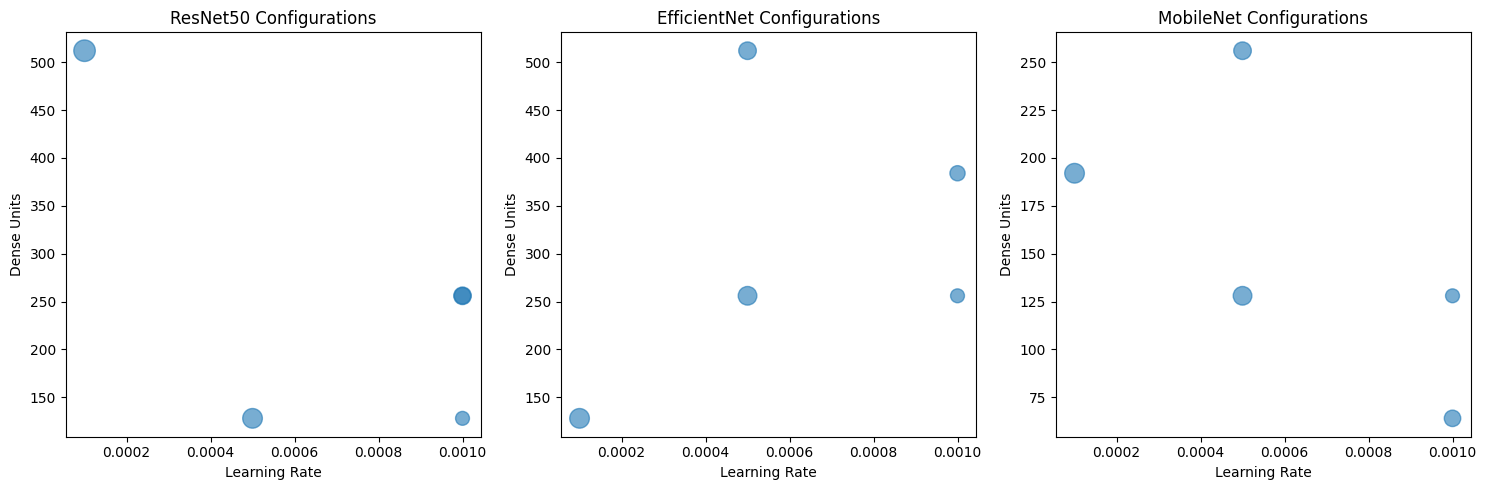

In [18]:
# Visualisation de la configuration
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ResNet Grid
resnet_df = pd.DataFrame(RESNET_GRID)
axes[0].scatter(resnet_df['learning_rate'], resnet_df['dense_units'], s=resnet_df['epochs']*20, alpha=0.6)
axes[0].set_title('ResNet50 Configurations')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Dense Units')

# EfficientNet Grid
effnet_df = pd.DataFrame(EFFICIENTNET_GRID)
axes[1].scatter(effnet_df['learning_rate'], effnet_df['dense_units'], s=effnet_df['epochs']*20, alpha=0.6)
axes[1].set_title('EfficientNet Configurations')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Dense Units')

# MobileNet Grid
mobilenet_df = pd.DataFrame(MOBILENET_GRID)
axes[2].scatter(mobilenet_df['learning_rate'], mobilenet_df['dense_units'], s=mobilenet_df['epochs']*20, alpha=0.6)
axes[2].set_title('MobileNet Configurations')
axes[2].set_xlabel('Learning Rate')
axes[2].set_ylabel('Dense Units')

plt.tight_layout()
plt.show()

## 10. Fonction générique pour exécuter une expérience


In [19]:
def run_experiment_with_experiment(config, experiment_num, model_type, experiment_name=None):
    """Exécute une expérience MLflow avec configuration donnée et expérience spécifique"""
    
    if experiment_name:
        mlflow.set_experiment(experiment_name)
    
    run_name = f"{model_type}_exp_{experiment_num:02d}"
    
    print(f"\n{'='*60}")
    print(f"Expérience {experiment_num}: {run_name}")
    print(f"Expérience MLflow: {experiment_name}")
    print(f"Configuration: {config}")
    print(f"{'='*60}")
    
    try:
        with mlflow.start_run(run_name=run_name):
            # Logger TOUS les hyperparamètres
            mlflow.log_params({
                'model_type': model_type,
                'learning_rate': config['learning_rate'],
                'dropout_rate': config['dropout_rate'],
                'l2_reg': config['l2_reg'],
                'dense_units': config['dense_units'],
                'freeze_backbone': config.get('freeze_backbone', True),
                'epochs': config['epochs'],
                'batch_size': 32,
                'num_classes': loader.num_classes,
                'dataset': 'sipakmed_new6',
                'image_size': '224x224'
            })
            
            # Logger les infos du dataset
            mlflow.log_params({
                'class_names': str(loader.class_names),
                'train_samples': int(train_gen.samples),
                'test_samples': int(test_gen.samples)
            })
            
            # Sélectionner le bon modèle
            if model_type == 'resnet50':
                model = create_resnet50_model(loader.num_classes, config)
            elif model_type == 'efficientnet':
                model = create_efficientnet_model(loader.num_classes, config)
            elif model_type == 'mobilenet':
                model = create_mobilenet_model(loader.num_classes, config)
            else:
                raise ValueError(f"Type de modèle inconnu: {model_type}")
            
            # Callbacks
            callbacks_list = [
                EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
            ]
            
            # Entraînement
            print(f"Entraînement ({config['epochs']} epochs)...")
            
            steps_per_epoch = max(1, train_gen.samples // train_gen.batch_size)
            validation_steps = max(1, test_gen.samples // test_gen.batch_size)
            
            history = model.fit(
                train_gen,
                steps_per_epoch=steps_per_epoch,
                epochs=config['epochs'],
                validation_data=test_gen,
                validation_steps=validation_steps,
                callbacks=callbacks_list,
                verbose=1
            )
            
            # Évaluation
            test_loss, test_accuracy = evaluate_model_safely(model, test_gen)
            metrics, _, _ = calculate_comprehensive_metrics(model, test_gen)
            metrics['test_loss'] = float(test_loss)
            metrics['test_accuracy'] = float(test_accuracy)
            
            # Logger les métriques
            mlflow.log_metrics(metrics)
            
            # Logger l'historique d'entraînement
            for epoch in range(len(history.history.get('accuracy', []))):
                epoch_metrics = {
                    'train_accuracy': float(history.history['accuracy'][epoch]),
                    'train_loss': float(history.history['loss'][epoch])
                }
                
                if 'val_accuracy' in history.history and epoch < len(history.history['val_accuracy']):
                    epoch_metrics['val_accuracy'] = float(history.history['val_accuracy'][epoch])
                if 'val_loss' in history.history and epoch < len(history.history['val_loss']):
                    epoch_metrics['val_loss'] = float(history.history['val_loss'][epoch])
                    
                mlflow.log_metrics(epoch_metrics, step=epoch+1)
            
            # Sauvegarder le modèle
            mlflow.keras.log_model(model, "model")
            
            # Créer un rapport détaillé
            report_data = safe_serialize({
                'experiment_info': {
                    'run_name': run_name,
                    'experiment_name': experiment_name,
                    'experiment_id': experiment_num,
                    'timestamp': datetime.now().isoformat()
                },
                'model_config': config,
                'training_history': {
                    'final_train_accuracy': float(history.history['accuracy'][-1]) if 'accuracy' in history.history else 0,
                    'final_train_loss': float(history.history['loss'][-1]) if 'loss' in history.history else 0,
                    'epochs_completed': len(history.history['accuracy']) if 'accuracy' in history.history else 0
                },
                'evaluation_metrics': metrics,
                'dataset_info': {
                    'num_classes': int(loader.num_classes),
                    'class_names': loader.class_names,
                    'train_samples': int(train_gen.samples),
                    'test_samples': int(test_gen.samples)
                },
                'model_summary': {
                    'total_params': int(model.count_params()),
                    'trainable_params': int(sum([np.prod(v.shape) for v in model.trainable_weights])),
                    'non_trainable_params': int(sum([np.prod(v.shape) for v in model.non_trainable_weights]))
                }
            })
            
            # Sauvegarder le rapport
            with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
                json.dump(report_data, f, indent=4, ensure_ascii=False)
                temp_path = f.name
            
            mlflow.log_artifact(temp_path, "report")
            os.unlink(temp_path)
            
            print(f"Accuracy: {metrics['accuracy']:.4f}")
            print(f"F1-Score: {metrics['f1_score']:.4f}")
            print(f"AUC-ROC: {metrics['auc_roc']:.4f}")
            
            return {
                'run_name': run_name,
                'experiment_name': experiment_name,
                'config': config,
                'metrics': metrics,
                'history': history.history
            }
            
    except Exception as e:
        print(f"ERREUR dans l'expérience {experiment_num}: {e}")
        # Ensure any active run is ended
        if mlflow.active_run() is not None:
            mlflow.end_run(status="FAILED")
        return None

## 11. GridSearch avec expériences séparées par modèle

In [20]:
print("\n" + "=" * 80)
print("DÉBUT DU GRIDSEARCH - EXPÉRIENCES SÉPARÉES")
print("=" * 80)

if mlflow.active_run() is not None:
    print(f"Nettoyage d'une run active: {mlflow.active_run().info.run_id}")
    mlflow.end_run()

all_results = []

# %%
print(f"\nRESNET50 - {len(RESNET_GRID)} configurations")
resnet_experiment_name = f"SipakMed_ResNet50_{datetime.now().strftime('%Y%m%d_%H%M')}"
print(f"Création de l'expérience: {resnet_experiment_name}")

resnet_results = []
for config_idx, config in enumerate(RESNET_GRID, 1):
    result = run_experiment_with_experiment(config, config_idx, 'resnet50', resnet_experiment_name)
    if result:
        all_results.append(result)
        resnet_results.append(result)

# %%
print(f"\nEFFICIENTNET - {len(EFFICIENTNET_GRID)} configurations")
efficientnet_experiment_name = f"SipakMed_EfficientNet_{datetime.now().strftime('%Y%m%d_%H%M')}"
print(f"Création de l'expérience: {efficientnet_experiment_name}")

efficientnet_results = []
for config_idx, config in enumerate(EFFICIENTNET_GRID, 1):
    result = run_experiment_with_experiment(config, config_idx, 'efficientnet', efficientnet_experiment_name)
    if result:
        all_results.append(result)
        efficientnet_results.append(result)

# %%
print(f"\nMOBILENET - {len(MOBILENET_GRID)} configurations")
mobilenet_experiment_name = f"SipakMed_MobileNet_{datetime.now().strftime('%Y%m%d_%H%M')}"
print(f"Création de l'expérience: {mobilenet_experiment_name}")

mobilenet_results = []
for config_idx, config in enumerate(MOBILENET_GRID, 1):
    result = run_experiment_with_experiment(config, config_idx, 'mobilenet', mobilenet_experiment_name)
    if result:
        all_results.append(result)
        mobilenet_results.append(result)

Traceback (most recent call last):
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 376, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 474, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1644, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1637, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r


DÉBUT DU GRIDSEARCH - EXPÉRIENCES SÉPARÉES
Nettoyage d'une run active: 5a5055a61c744ad4b99401330b3ef77a

RESNET50 - 5 configurations
Création de l'expérience: SipakMed_ResNet50_20251207_1733

Expérience 1: resnet50_exp_01
Expérience MLflow: SipakMed_ResNet50_20251207_1733
Configuration: {'learning_rate': 0.001, 'dropout_rate': 0.3, 'l2_reg': 0.01, 'dense_units': 128, 'epochs': 5, 'freeze_backbone': True, 'model_type': 'resnet50'}
  🏗️ Création ResNet50 avec config: {'learning_rate': 0.001, 'dropout_rate': 0.3, 'l2_reg': 0.01, 'dense_units': 128, 'epochs': 5, 'freeze_backbone': True, 'model_type': 'resnet50'}
Entraînement (5 epochs)...
Epoch 1/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.6281 - loss: 3.1590 - val_accuracy: 0.7232 - val_loss: 2.5743 - learning_rate: 0.0010
Epoch 2/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 876ms/step - accuracy: 0.7500 - loss: 2.5799 - val_accuracy: 0.7288 - val_loss: 2.5221 - learning_rate: 0.0010
Epoch 3/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accu

2025/12/07 17:37:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/07 17:37:12 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/12/07 17:37:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Traceback (most recent call last):
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 376, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 474, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", lin

Accuracy: 0.8475
F1-Score: 0.8499
AUC-ROC: 0.9601

Expérience 2: resnet50_exp_02
Expérience MLflow: SipakMed_ResNet50_20251207_1733
Configuration: {'learning_rate': 0.001, 'dropout_rate': 0.5, 'l2_reg': 0.01, 'dense_units': 256, 'epochs': 8, 'freeze_backbone': True, 'model_type': 'resnet50'}
  🏗️ Création ResNet50 avec config: {'learning_rate': 0.001, 'dropout_rate': 0.5, 'l2_reg': 0.01, 'dense_units': 256, 'epochs': 8, 'freeze_backbone': True, 'model_type': 'resnet50'}
Entraînement (8 epochs)...
Epoch 1/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.6185 - loss: 5.1517 - val_accuracy: 0.5198 - val_loss: 4.9606 - learning_rate: 0.0010
Epoch 2/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6875 - loss: 4.6048 - val_accuracy: 0.5593 - val_loss: 4.8305 - learning_rate: 0.0010
Epoch 3/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.7707 - loss: 3.8660 - val_accuracy: 0.7797 - val_loss: 3.4019 - learning_rate: 0.0010
Epoch 4/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 921ms/step

2025/12/07 17:42:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/07 17:42:39 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/12/07 17:42:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Traceback (most recent call last):
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 376, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 474, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", lin

...

Accuracy: 0.6102
F1-Score: 0.5762
AUC-ROC: 0.8053

Expérience 4: mobilenet_exp_04
Expérience MLflow: SipakMed_MobileNet_20251207_1828
Configuration: {'learning_rate': 0.001, 'dropout_rate': 0.2, 'l2_reg': 0.005, 'dense_units': 64, 'epochs': 7, 'freeze_backbone': False, 'model_type': 'mobilenet'}
  🏗️ Création MobileNet avec config: {'learning_rate': 0.001, 'dropout_rate': 0.2, 'l2_reg': 0.005, 'dense_units': 64, 'epochs': 7, 'freeze_backbone': False, 'model_type': 'mobilenet'}
Entraînement (7 epochs)...
Epoch 1/7
17/17 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.6686 - loss: 1.5556 - val_accuracy: 0.2147 - val_loss: 2.8601 - learning_rate: 0.0010
Epoch 2/7
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step - accuracy: 0.8125 - loss: 1.1587 - val_accuracy: 0.2260 - val_loss: 3.0314 - learning_rate: 0.0010
Epoch 3/7
17/17 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - accuracy: 0.7996 - loss: 1.1023 - val_accuracy: 0.2373 - val_loss: 7.4908 - learning_rate: 0.0010
Epoch 4/7
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 4

2025/12/07 18:40:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/07 18:40:04 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/12/07 18:40:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Traceback (most recent call last):
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 376, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 474, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\sarah\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", lin

Accuracy: 0.2147
F1-Score: 0.0950
AUC-ROC: 0.3539

Expérience 5: mobilenet_exp_05
Expérience MLflow: SipakMed_MobileNet_20251207_1828
Configuration: {'learning_rate': 0.0005, 'dropout_rate': 0.3, 'l2_reg': 0.01, 'dense_units': 128, 'epochs': 9, 'freeze_backbone': True, 'model_type': 'mobilenet'}
  🏗️ Création MobileNet avec config: {'learning_rate': 0.0005, 'dropout_rate': 0.3, 'l2_reg': 0.01, 'dense_units': 128, 'epochs': 9, 'freeze_backbone': True, 'model_type': 'mobilenet'}
Entraînement (9 epochs)...
Epoch 1/9
17/17 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.5356 - loss: 3.3768 - val_accuracy: 0.3672 - val_loss: 3.5557 - learning_rate: 5.0000e-04
Epoch 2/9
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 670ms/step - accuracy: 0.7188 - loss: 2.6538 - val_accuracy: 0.3785 - val_loss: 3.4843 - learning_rate: 5.0000e-04
Epoch 3/9
17/17 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.6705 - loss: 2.7471 - val_accuracy: 0.4520 - val_loss: 2.8815 - learning_rate: 5.0000e-04
Epoch 4/9
17/17 ━━━━━━━━━━━━━

2025/12/07 18:46:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/07 18:46:07 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/12/07 18:46:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy: 0.6497
F1-Score: 0.6313
AUC-ROC: 0.8471


## 12. Analyse & Rapport final
Cette cellule :
- Résume toutes les expériences,
- Trouve le **meilleur modèle**,
- Sauvegarde un rapport JSON dans `mlruns/`.


In [21]:
print("\n" + "=" * 80)
print("RAPPORT FINAL - SIPAKMED CLASSIFICATION")
print("=" * 80)

print(f"\nEXPÉRIENCES TERMINÉES: {len(all_results)}")
print(f"DATASET: SipakMed (images cytologiques)")
print(f"CLASSES: {loader.num_classes} classes")
print(f"CLASSES TROUVÉES: {', '.join(loader.class_names)}")

if all_results:
    # Récupérer les noms des expériences créées
    all_experiment_names = set([r.get('experiment_name', EXPERIMENT_NAME) for r in all_results])
    
    print(f"\nEXPÉRIENCES MLFLOW CRÉÉES:")
    for exp_name in all_experiment_names:
        exp_runs = [r for r in all_results if r.get('experiment_name') == exp_name]
        print(f"   • {exp_name}: {len(exp_runs)} runs")
    
    # Trouver le meilleur modèle parmi toutes les expériences
    best_result = max(all_results, key=lambda x: x['metrics']['accuracy'])
    
    print(f"\nMEILLEUR MODÈLE GLOBAL:")
    print(f"   - Expérience: {best_result.get('experiment_name', 'N/A')}")
    print(f"   - Run: {best_result['run_name']}")
    print(f"   - Type: {best_result['config'].get('model_type', 'resnet50')}")
    print(f"   - Accuracy: {best_result['metrics']['accuracy']:.4f}")
    print(f"   - F1-Score: {best_result['metrics']['f1_score']:.4f}")
    print(f"   - AUC-ROC: {best_result['metrics'].get('auc_roc', 0):.4f}")
    
    # Statistiques par type de modèle (utiliser les listes que nous avons déjà)
    print(f"\nSTATISTIQUES PAR MODÈLE:")
    
    if resnet_results:
        acc_resnet = np.mean([r['metrics']['accuracy'] for r in resnet_results])
        f1_resnet = np.mean([r['metrics']['f1_score'] for r in resnet_results])
        best_resnet = max(resnet_results, key=lambda x: x['metrics']['accuracy'])
        print(f"   • ResNet50: Accuracy={acc_resnet:.4f}, F1={f1_resnet:.4f} ({len(resnet_results)} exp)")
        print(f"     Meilleur ResNet50: {best_resnet['run_name']} (Accuracy: {best_resnet['metrics']['accuracy']:.4f})")
    
    if efficientnet_results:
        acc_eff = np.mean([r['metrics']['accuracy'] for r in efficientnet_results])
        f1_eff = np.mean([r['metrics']['f1_score'] for r in efficientnet_results])
        best_eff = max(efficientnet_results, key=lambda x: x['metrics']['accuracy'])
        print(f"   • EfficientNet: Accuracy={acc_eff:.4f}, F1={f1_eff:.4f} ({len(efficientnet_results)} exp)")
        print(f"     Meilleur EfficientNet: {best_eff['run_name']} (Accuracy: {best_eff['metrics']['accuracy']:.4f})")
    
    if mobilenet_results:
        acc_mob = np.mean([r['metrics']['accuracy'] for r in mobilenet_results])
        f1_mob = np.mean([r['metrics']['f1_score'] for r in mobilenet_results])
        best_mob = max(mobilenet_results, key=lambda x: x['metrics']['accuracy'])
        print(f"   • MobileNet: Accuracy={acc_mob:.4f}, F1={f1_mob:.4f} ({len(mobilenet_results)} exp)")
        print(f"     Meilleur MobileNet: {best_mob['run_name']} (Accuracy: {best_mob['metrics']['accuracy']:.4f})")
    
    # Top 5 modèles
    print(f"\nTOP 5 MODÈLES:")
    sorted_results = sorted(all_results, key=lambda x: x['metrics']['accuracy'], reverse=True)[:5]
    for i, result in enumerate(sorted_results):
        exp_name = result.get('experiment_name', 'Default')
        print(f"   {i+1}. [{exp_name}] {result['run_name']}:")
        print(f"       Accuracy={result['metrics']['accuracy']:.4f}, F1={result['metrics']['f1_score']:.4f}")
        print(f"       LR={result['config']['learning_rate']}, Dropout={result['config']['dropout_rate']}, Units={result['config']['dense_units']}")


RAPPORT FINAL - SIPAKMED CLASSIFICATION

EXPÉRIENCES TERMINÉES: 15
DATASET: SipakMed (images cytologiques)
CLASSES: 3 classes
CLASSES TROUVÉES: Abnormal, Benign, Normal

EXPÉRIENCES MLFLOW CRÉÉES:
   • SipakMed_ResNet50_20251207_1733: 5 runs
   • SipakMed_EfficientNet_20251207_1809: 5 runs
   • SipakMed_MobileNet_20251207_1828: 5 runs

MEILLEUR MODÈLE GLOBAL:
   - Expérience: SipakMed_ResNet50_20251207_1733
   - Run: resnet50_exp_02
   - Type: resnet50
   - Accuracy: 0.9209
   - F1-Score: 0.9211
   - AUC-ROC: 0.9734

STATISTIQUES PAR MODÈLE:
   • ResNet50: Accuracy=0.8000, F1=0.7761 (5 exp)
     Meilleur ResNet50: resnet50_exp_02 (Accuracy: 0.9209)
   • EfficientNet: Accuracy=0.8158, F1=0.8164 (5 exp)
     Meilleur EfficientNet: efficientnet_exp_02 (Accuracy: 0.8757)
   • MobileNet: Accuracy=0.5480, F1=0.5061 (5 exp)
     Meilleur MobileNet: mobilenet_exp_01 (Accuracy: 0.6667)

TOP 5 MODÈLES:
   1. [SipakMed_ResNet50_20251207_1733] resnet50_exp_02:
       Accuracy=0.9209, F1=0.9211
  

## 13. Sauvegarde du rapport final


RAPPORT SAUVEGARDÉ DANS MLRUNS: c:\Users\sarah\Documents\M Info\M2 SID\AASD\Apprentisaage\mlruns\sipakmed_mlflow_report_20251207_1850.json


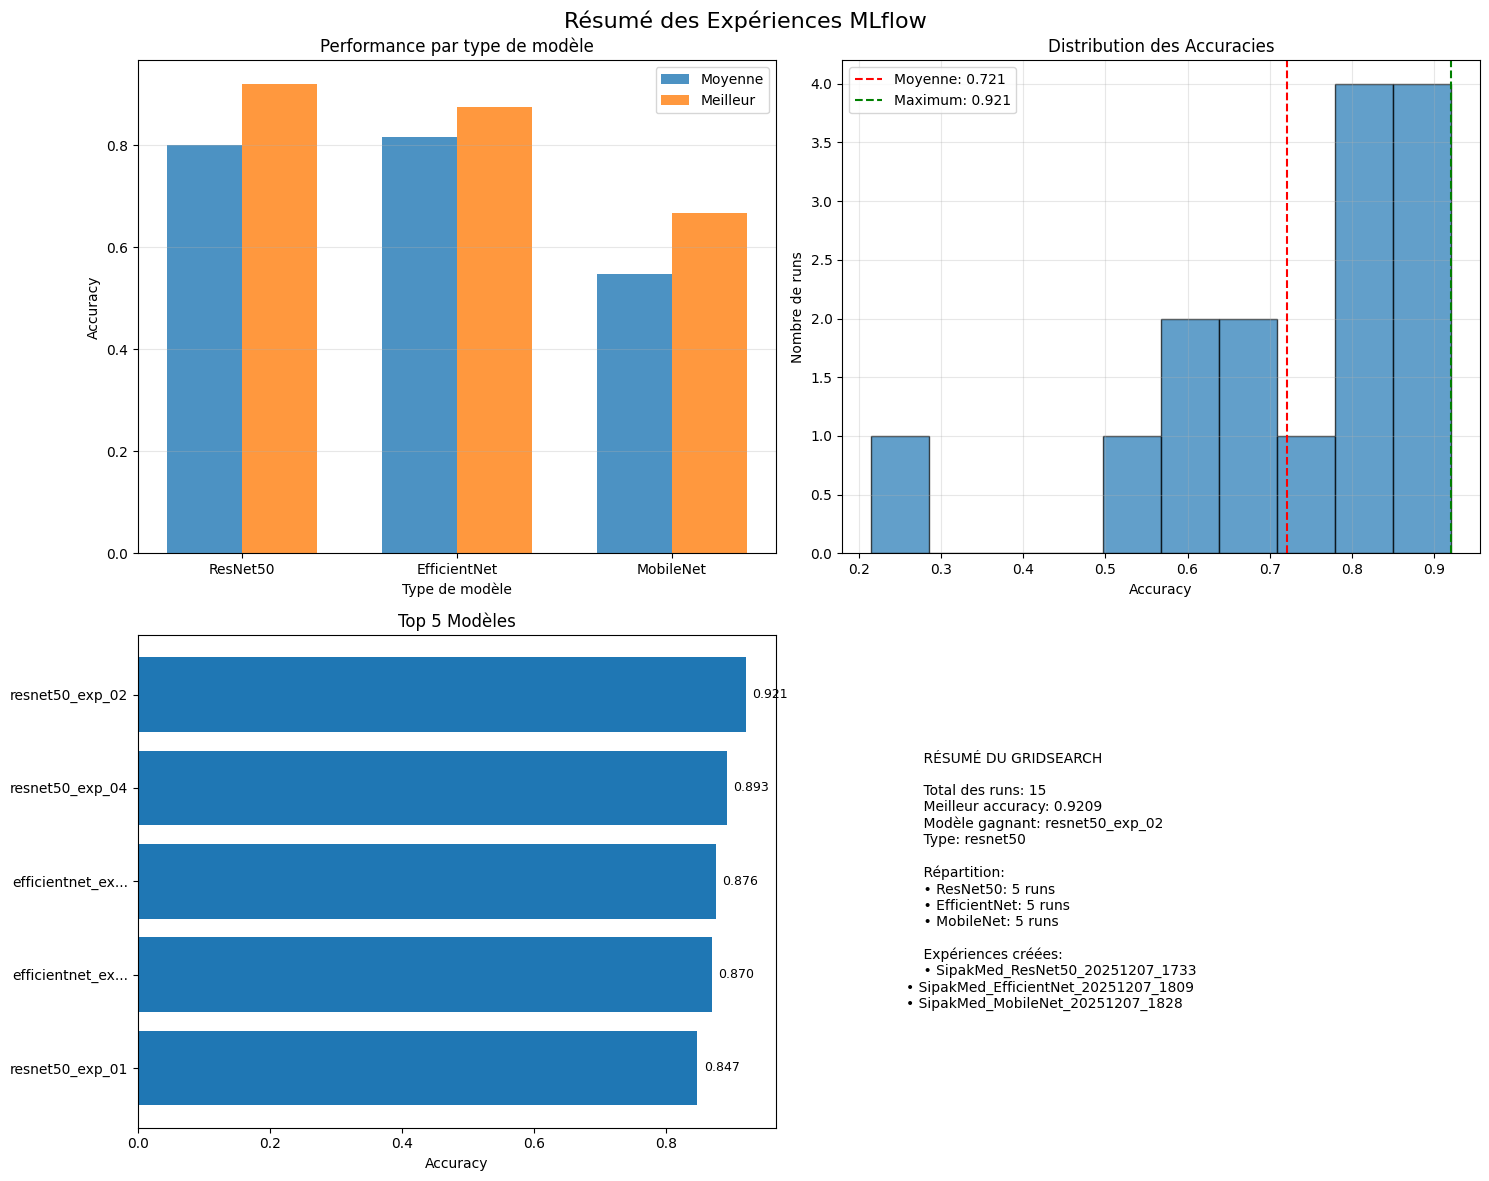


Visualisation sauvegardée: gridsearch_summary.png
   • SipakMed_ResNet50_20251207_1733 (5 runs)
   • SipakMed_EfficientNet_20251207_1809 (5 runs)
   • SipakMed_MobileNet_20251207_1828 (5 runs)


In [22]:
if all_results:
    # Sauvegarder le rapport final
    final_report = safe_serialize({
        'project': 'SipakMed Classification MLOps',
        'date': datetime.now().isoformat(),
        'dataset': {
            'name': 'sipakmed_new6',
            'path': DATA_PATH,
            'classes': loader.class_names,
            'num_classes': loader.num_classes,
            'train_samples': int(train_gen.samples),
            'test_samples': int(test_gen.samples)
        },
        'experiments_summary': {
            'total_experiments_created': len(all_experiment_names),
            'experiment_names': list(all_experiment_names),
            'total_runs': len(all_results),
            'resnet_runs': len(resnet_results),
            'efficientnet_runs': len(efficientnet_results),
            'mobilenet_runs': len(mobilenet_results)
        },
        'performance_summary': {
            'best_accuracy': float(best_result['metrics']['accuracy']),
            'best_f1_score': float(best_result['metrics']['f1_score']),
            'best_model': {
                'run_name': best_result['run_name'],
                'experiment_name': best_result.get('experiment_name', 'N/A'),
                'model_type': best_result['config'].get('model_type', 'N/A'),
                'accuracy': float(best_result['metrics']['accuracy'])
            },
            'model_type_comparison': {
                'resnet50': {
                    'avg_accuracy': float(np.mean([r['metrics']['accuracy'] for r in resnet_results])) if resnet_results else 0,
                    'best_accuracy': float(max([r['metrics']['accuracy'] for r in resnet_results])) if resnet_results else 0,
                    'num_runs': len(resnet_results)
                },
                'efficientnet': {
                    'avg_accuracy': float(np.mean([r['metrics']['accuracy'] for r in efficientnet_results])) if efficientnet_results else 0,
                    'best_accuracy': float(max([r['metrics']['accuracy'] for r in efficientnet_results])) if efficientnet_results else 0,
                    'num_runs': len(efficientnet_results)
                },
                'mobilenet': {
                    'avg_accuracy': float(np.mean([r['metrics']['accuracy'] for r in mobilenet_results])) if mobilenet_results else 0,
                    'best_accuracy': float(max([r['metrics']['accuracy'] for r in mobilenet_results])) if mobilenet_results else 0,
                    'num_runs': len(mobilenet_results)
                }
            }
        },
        'top_5_models': [
            {
                'rank': i+1,
                'run_name': result['run_name'],
                'experiment_name': result.get('experiment_name', 'N/A'),
                'model_type': result['config'].get('model_type', 'N/A'),
                'config': result['config'],
                'metrics': result['metrics']
            }
            for i, result in enumerate(sorted_results[:5])
        ],
        'mlflow_info': {
            'tracking_uri': mlflow.get_tracking_uri(),
            'experiments_created': list(all_experiment_names),
            'artifact_root': mlrun_dir
        }
    })
    
    # Sauvegarder le rapport dans mlruns
    report_filename = f"sipakmed_mlflow_report_{datetime.now().strftime('%Y%m%d_%H%M')}.json"
    report_path = os.path.join(mlrun_dir, report_filename)

    with open(report_path, 'w', encoding='utf-8') as f:
        json.dump(final_report, f, indent=4, ensure_ascii=False)

    print(f"\nRAPPORT SAUVEGARDÉ DANS MLRUNS: {report_path}")
    
    # Afficher un résumé visuel
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Résumé des Expériences MLflow', fontsize=16)
    
    # 1. Accuracy par type de modèle
    model_types = []
    avg_accuracies = []
    best_accuracies = []
    
    if resnet_results:
        model_types.append('ResNet50')
        avg_accuracies.append(np.mean([r['metrics']['accuracy'] for r in resnet_results]))
        best_accuracies.append(max([r['metrics']['accuracy'] for r in resnet_results]))
    
    if efficientnet_results:
        model_types.append('EfficientNet')
        avg_accuracies.append(np.mean([r['metrics']['accuracy'] for r in efficientnet_results]))
        best_accuracies.append(max([r['metrics']['accuracy'] for r in efficientnet_results]))
    
    if mobilenet_results:
        model_types.append('MobileNet')
        avg_accuracies.append(np.mean([r['metrics']['accuracy'] for r in mobilenet_results]))
        best_accuracies.append(max([r['metrics']['accuracy'] for r in mobilenet_results]))
    
    x = np.arange(len(model_types))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, avg_accuracies, width, label='Moyenne', alpha=0.8)
    axes[0, 0].bar(x + width/2, best_accuracies, width, label='Meilleur', alpha=0.8)
    axes[0, 0].set_xlabel('Type de modèle')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_title('Performance par type de modèle')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(model_types)
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Distribution des accuracies
    all_accuracies = [r['metrics']['accuracy'] for r in all_results]
    axes[0, 1].hist(all_accuracies, bins=10, edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(np.mean(all_accuracies), color='red', linestyle='--', label=f'Moyenne: {np.mean(all_accuracies):.3f}')
    axes[0, 1].axvline(np.max(all_accuracies), color='green', linestyle='--', label=f'Maximum: {np.max(all_accuracies):.3f}')
    axes[0, 1].set_xlabel('Accuracy')
    axes[0, 1].set_ylabel('Nombre de runs')
    axes[0, 1].set_title('Distribution des Accuracies')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # 3. Top 5 modèles
    top_5_names = [r['run_name'][:15] + '...' if len(r['run_name']) > 15 else r['run_name'] for r in sorted_results[:5]]
    top_5_acc = [r['metrics']['accuracy'] for r in sorted_results[:5]]
    
    bars = axes[1, 0].barh(range(len(top_5_names)), top_5_acc)
    axes[1, 0].set_yticks(range(len(top_5_names)))
    axes[1, 0].set_yticklabels(top_5_names)
    axes[1, 0].set_xlabel('Accuracy')
    axes[1, 0].set_title('Top 5 Modèles')
    axes[1, 0].invert_yaxis()  # Meilleur en haut
    
    # Ajouter les valeurs sur les barres
    for i, (bar, acc) in enumerate(zip(bars, top_5_acc)):
        width = bar.get_width()
        axes[1, 0].text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.3f}', 
                       va='center', fontsize=9)
    
    # 4. Résumé textuel
    axes[1, 1].axis('off')
    summary_text = f"""
    RÉSUMÉ DU GRIDSEARCH
    
    Total des runs: {len(all_results)}
    Meilleur accuracy: {best_result['metrics']['accuracy']:.4f}
    Modèle gagnant: {best_result['run_name']}
    Type: {best_result['config'].get('model_type', 'N/A')}
    
    Répartition:
    • ResNet50: {len(resnet_results)} runs
    • EfficientNet: {len(efficientnet_results)} runs  
    • MobileNet: {len(mobilenet_results)} runs
    
    Expériences créées:
    """
    for exp_name in all_experiment_names:
        summary_text += f"• {exp_name}\n"
    
    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=10, 
                   verticalalignment='center', transform=axes[1, 1].transAxes)
    
    plt.tight_layout()
    plt.savefig('gridsearch_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nVisualisation sauvegardée: gridsearch_summary.png")


if all_results:
    all_experiment_names = set([r.get('experiment_name', EXPERIMENT_NAME) for r in all_results])
    for exp_name in all_experiment_names:
        exp_runs = [r for r in all_results if r.get('experiment_name') == exp_name]
        print(f"   • {exp_name} ({len(exp_runs)} runs)")

### Chargement des modèles entrainés .h5

In [ ]:
import mlflow
import tensorflow as tf
import os
import shutil
from pathlib import Path

# Set tracking URI
mlflow.set_tracking_uri("http://localhost:5000")

# Your run IDs
run_ids = {
    "resnet02": "226285f095c844f1b30dcae8583f8a3a",
    "efficientnet02": "5f50d7edb4f2430eac48f91877dc46ef", 
    "mobilenet01": "3df0371bc2b94d69b1b45643a02e762f"
}

models_dir = Path.cwd().parent / "src" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Clean up the corrupted temp file
temp_file = models_dir / "temp_model.h5"
if temp_file.exists():
    temp_file.unlink()
    print(f"Removed corrupted temp file")

print("\n" + "=" * 60)
print("DOWNLOADING MODELS FOR KERAS 3")
print("=" * 60)

def save_model_keras3(model, output_path):
    """Save model compatible with Keras 3"""
    try:
        # Try saving with .keras extension (new Keras 3 format)
        if str(output_path).endswith('.h5'):
            keras3_path = output_path.with_suffix('.keras')
            model.save(str(keras3_path))
            print(f"Saved as Keras 3 format: {keras3_path.name}")

            try:
                model.save(str(output_path))
                print(f"Also saved as .h5: {output_path.name}")
                return True
            except:
                return True
        else:
            model.save(str(output_path))
            return True
            
    except Exception as e:
        print(f"Keras 3 save failed: {e}")
        return False

for model_name, run_id in run_ids.items():
    print(f"\nProcessing {model_name}...")
    
    try:
        # Load model from MLflow
        print(f"   1. Loading from MLflow...")
        model = mlflow.keras.load_model(f"runs:/{run_id}/model")
        
        print(f"Loaded successfully!")
        print(f"Input: {model.input_shape}")
        print(f"Output: {model.output_shape}")
        
        # Save the model
        print(f"2. Saving model...")
        
        # Save as .keras (Keras 3 native format)
        keras_path = models_dir / f"{model_name}.keras"
        try:
            model.save(str(keras_path))
            print(f"Saved as: {keras_path.name}")
        except Exception as e:
            print(f"Failed to save as .keras: {e}")
        
        # Also try to save as .h5 (for compatibility)
        h5_path = models_dir / f"{model_name}.h5"
        try:
            # For Keras 3 with .h5, we need to handle it differently
            if hasattr(model, '_save_to_hdf5'):
                # Legacy method for HDF5
                model._save_to_hdf5(str(h5_path))
                print(f"Also saved as .h5: {h5_path.name}")
            else:
                # Try standard save
                model.save(str(h5_path))
                print(f"Saved as .h5: {h5_path.name}")
        except Exception as e:
            print(f"Could not save as .h5: {e}")
            print(f"Using .keras format instead")
        
    except Exception as e:
        print(f"Error: {e}")


DOWNLOADING MODELS FOR KERAS 3

Processing resnet02...
   1. Loading from MLflow...


Loaded successfully!
Input: (None, 224, 224, 3)
Output: (None, 3)
2. Saving model...


Saved as: resnet02.keras
Saved as .h5: resnet02.h5

Processing efficientnet02...
   1. Loading from MLflow...


Loaded successfully!
Input: (None, 224, 224, 3)
Output: (None, 3)
2. Saving model...


Saved as: efficientnet02.keras
Could not save as .h5: cannot pickle 'module' object
Using .keras format instead

Processing mobilenet01...
   1. Loading from MLflow...


Loaded successfully!
Input: (None, 224, 224, 3)
Output: (None, 3)
2. Saving model...


Saved as: mobilenet01.keras
Could not save as .h5: cannot pickle 'module' object
Using .keras format instead


## 14. Prochaines étapes du projet MLOps


#### Lancement de MLflow UI

1. Pour voir les expériences avec l'UI MLFlow, taper la commande <code>./run_mlflow.bat"</code> dans un terminal puis cliquer sur <code>http://127.0.0.1:5000</code>
<br></br>
2. Sinon, cliquer sur le lien suivant :
    <code>http://localhost:5000</code>

#### Explicabilité avec LIME 